# Лабораторная работа №1: Проведение исследований с алгоритмом KNN

## Цель работы
Исследование алгоритма k-ближайших соседей (KNN) для задач классификации и регрессии на реальных данных. Работа включает создание бейзлайна, его улучшение и самостоятельную имплементацию алгоритма.

## Выбор датасетов
- **Классификация:** "Human Activity Recognition with Smartphones" — данные с акселерометра и гироскопа смартфона для определения активности человека (ходьба, сидение и т.д.). Практическая задача: мониторинг физической активности в приложениях здоровья и фитнеса.
- **Регрессия:** "CO2 Emission by Vehicles" — характеристики автомобилей и уровень выбросов CO₂. Практическая задача: прогнозирование выбросов для экологического регулирования и оценки воздействия на окружающую среду.

Датасеты загружены из Kaggle и размещены локально.

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## Загрузка данных
Загрузим данные для классификации (уже разделенные на train и test) и для регрессии (требуется разделение).

In [25]:
# Загрузка данных для классификации
train_class = pd.read_csv('datasets/HUMAN_ACTIVITY/train.csv')
test_class = pd.read_csv('datasets/HUMAN_ACTIVITY/test.csv')

# Загрузка данных для регрессии
data_reg = pd.read_csv('datasets/CO2/CO2_dataset.csv')

print("Данные классификации загружены:")
print(f"  Train: {train_class.shape}, Test: {test_class.shape}")
print(f"\nДанные регрессии загружены: {data_reg.shape}")

Данные классификации загружены:
  Train: (7352, 563), Test: (2947, 563)

Данные регрессии загружены: (7385, 12)


## Предварительный анализ данных
Изучим структуру данных, проверим пропуски, распределения целевых переменных.

In [26]:
# Анализ данных классификации
print("=== АНАЛИЗ ДАННЫХ КЛАССИФИКАЦИИ ===")
print(f"Размер тренировочной выборки (классификация): {train_class.shape}")
print(f"Размер тестовой выборки (классификация): {test_class.shape}")
print(f"Количество признаков (без учета целевой переменной): {train_class.shape[1] - 1}")
print(f"Целевая переменная: 'Activity' - категориальная с {train_class['Activity'].nunique()} классами")

print("\nПервые 3 строки тренировочных данных:")
print(train_class.iloc[:, :5].head(3))  # Показываем только первые 5 признаков для наглядности

# Анализ типов данных
print("\nАнализ типов данных в датасете классификации:")
print(train_class.dtypes.value_counts())

print("\nСтатистика по пропущенным значениям:")
print(f"Общее количество пропущенных значений: {train_class.isnull().sum().sum()}")
print(f"Доля пропущенных значений: {train_class.isnull().sum().sum() / (train_class.shape[0] * train_class.shape[1]) * 100:.4f}%")

# Распределение целевой переменной
print("\nРаспределение целевой переменной (Activity):")
activity_distribution = train_class['Activity'].value_counts()
print(activity_distribution)
print(f"\nБаланс классов: максимальный класс {activity_distribution.max()/activity_distribution.min():.2f} раз больше минимального")

# Статистика по числовым признакам
print("\nОбщая статистика по числовым признакам:")
print(train_class.select_dtypes(include=[np.number]).describe().transpose().head(10))  # Первые 10 признаков

# Анализ данных регрессии
print("\n=== АНАЛИЗ ДАННЫХ РЕГРЕССИИ ===")
print(f"Размер датасета регрессии: {data_reg.shape}")
print(f"Количество признаков: {data_reg.shape[1] - 1}")
print(f"Целевая переменная: 'CO2 Emissions(g/km)' - непрерывная числовая переменная")

print("\nТипы данных в датасете регрессии:")
print(data_reg.dtypes)

print("\nКоличество уникальных значений для категориальных признаков:")
categorical_cols = data_reg.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {data_reg[col].nunique()} уникальных значений")

print("\nОписательные статистики целевой переменной (CO2 Emissions(g/km)):")
co2_stats = data_reg['CO2 Emissions(g/km)'].describe()
print(co2_stats)
print(f"\nКоэффициент вариации: {data_reg['CO2 Emissions(g/km)'].std() / data_reg['CO2 Emissions(g/km)'].mean() * 100:.2f}%")

# Проверка на выбросы для целевой переменной регрессии
Q1 = data_reg['CO2 Emissions(g/km)'].quantile(0.25)
Q3 = data_reg['CO2 Emissions(g/km)'].quantile(0.75)
IQR = Q3 - Q1
outliers = data_reg[(data_reg['CO2 Emissions(g/km)'] < Q1 - 1.5*IQR) | (data_reg['CO2 Emissions(g/km)'] > Q3 + 1.5*IQR)]
print(f"\nВыбросы в целевой переменной (по методу IQR): {len(outliers)} ({len(outliers)/len(data_reg)*100:.2f}% от данных)")

print("\nПроверка пропущенных значений в датасете регрессии:")
missing_values = data_reg.isnull().sum()
print(f"Признаки с пропущенными значениями: {missing_values[missing_values > 0].count()}")
print(f"Общее количество пропущенных значений: {missing_values.sum()}")

# Статистика по числовым признакам регрессии
numeric_cols_reg = data_reg.select_dtypes(include=[np.number]).columns
print("\nКорреляция числовых признаков с целевой переменной:")
correlations = data_reg[numeric_cols_reg].corr()['CO2 Emissions(g/km)'].sort_values(ascending=False)
for feature, corr in correlations.items():
    if feature != 'CO2 Emissions(g/km)':
        print(f"{feature}: {corr:.4f}")

=== АНАЛИЗ ДАННЫХ КЛАССИФИКАЦИИ ===
Размер тренировочной выборки (классификация): (7352, 563)
Размер тестовой выборки (классификация): (2947, 563)
Количество признаков (без учета целевой переменной): 562
Целевая переменная: 'Activity' - категориальная с 6 классами

Первые 3 строки тренировочных данных:
   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   

   tBodyAcc-std()-Y  
0         -0.983111  
1         -0.975300  
2         -0.967187  

Анализ типов данных в датасете классификации:
float64    561
int64        1
object       1
Name: count, dtype: int64

Статистика по пропущенным значениям:
Общее количество пропущенных значений: 0
Доля пропущенных значений: 0.0000%

Распределение целевой переменной (Activity):
Activity


## Визуализация данных для классификации

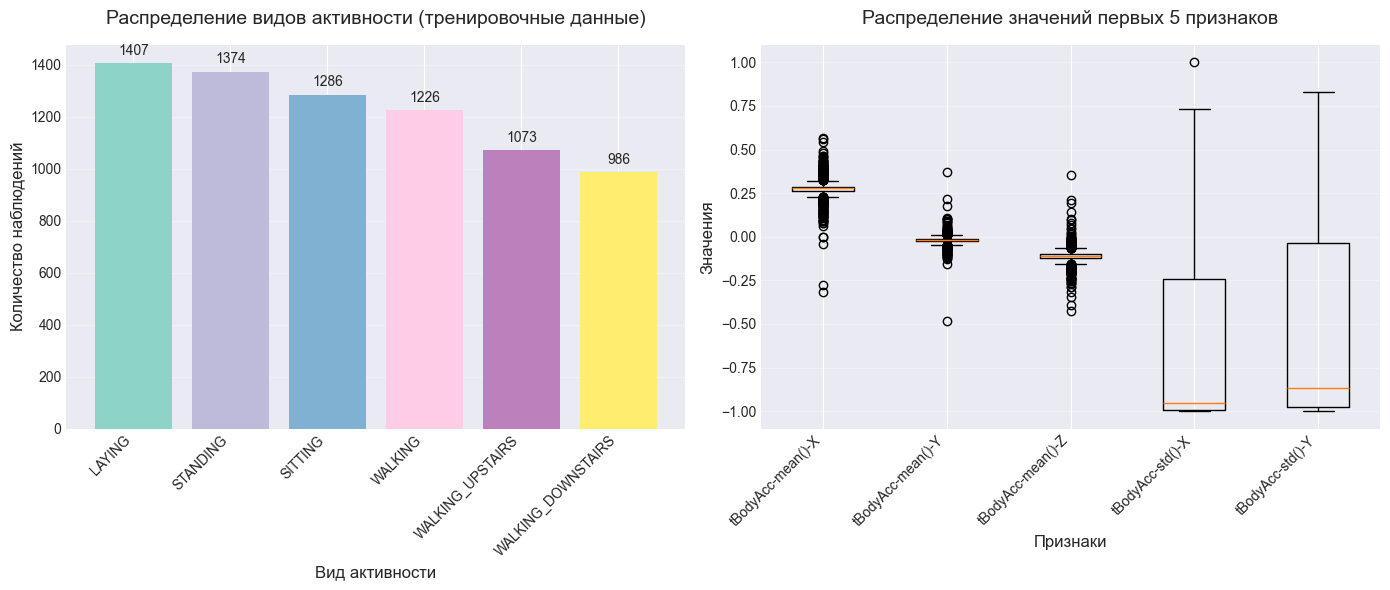

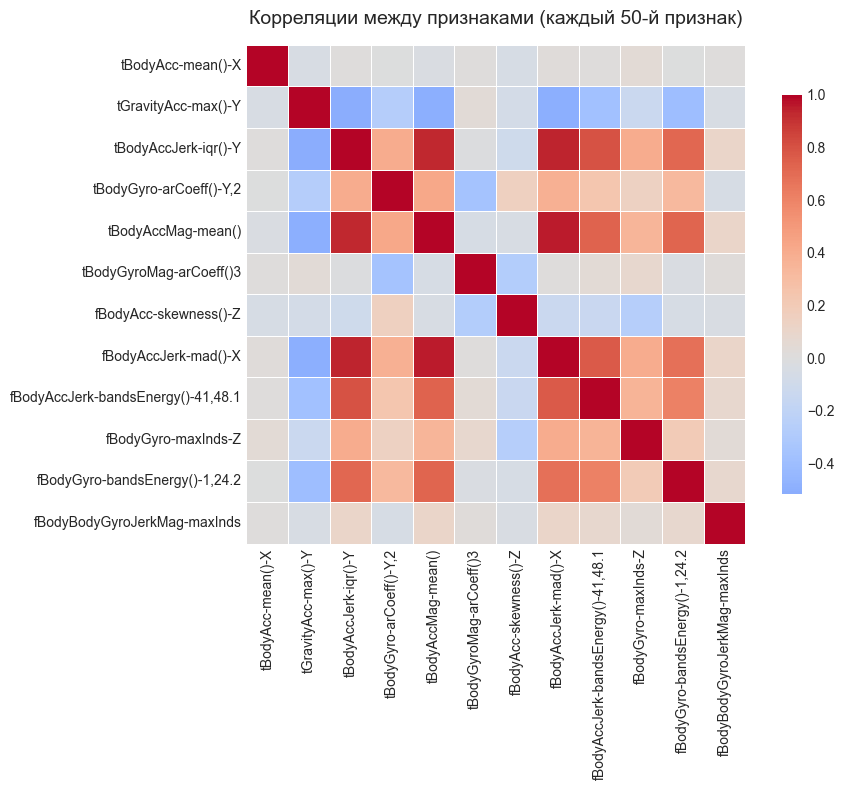

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

plt.figure(figsize=(14, 6))

# 1. Распределение активностей
plt.subplot(1, 2, 1)
activity_counts = train_class['Activity'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(activity_counts)))
bars = plt.bar(activity_counts.index, activity_counts.values, color=colors)
plt.title('Распределение видов активности (тренировочные данные)', fontsize=14, pad=15)
plt.xlabel('Вид активности', fontsize=12)
plt.ylabel('Количество наблюдений', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Добавление значений над столбцами
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{int(height)}', ha='center', va='bottom')

# 2. Статистика по числовым признакам (первые 5 признаков)
plt.subplot(1, 2, 2)
first_5_features = train_class.columns[:5]
train_sample = train_class[first_5_features].sample(n=1000, random_state=42)  # Для скорости
plt.boxplot([train_sample[col] for col in first_5_features], labels=first_5_features)
plt.title('Распределение значений первых 5 признаков', fontsize=14, pad=15)
plt.xlabel('Признаки', fontsize=12)
plt.ylabel('Значения', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Heatmap корреляций для части признаков
plt.figure(figsize=(10, 8))
# Выбираем каждый 50-й признак для визуализации корреляций
selected_features = train_class.select_dtypes(include=[np.number]).columns[::50]
corr_matrix = train_class[selected_features].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляции между признаками (каждый 50-й признак)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## Визуализация данных для регрессии

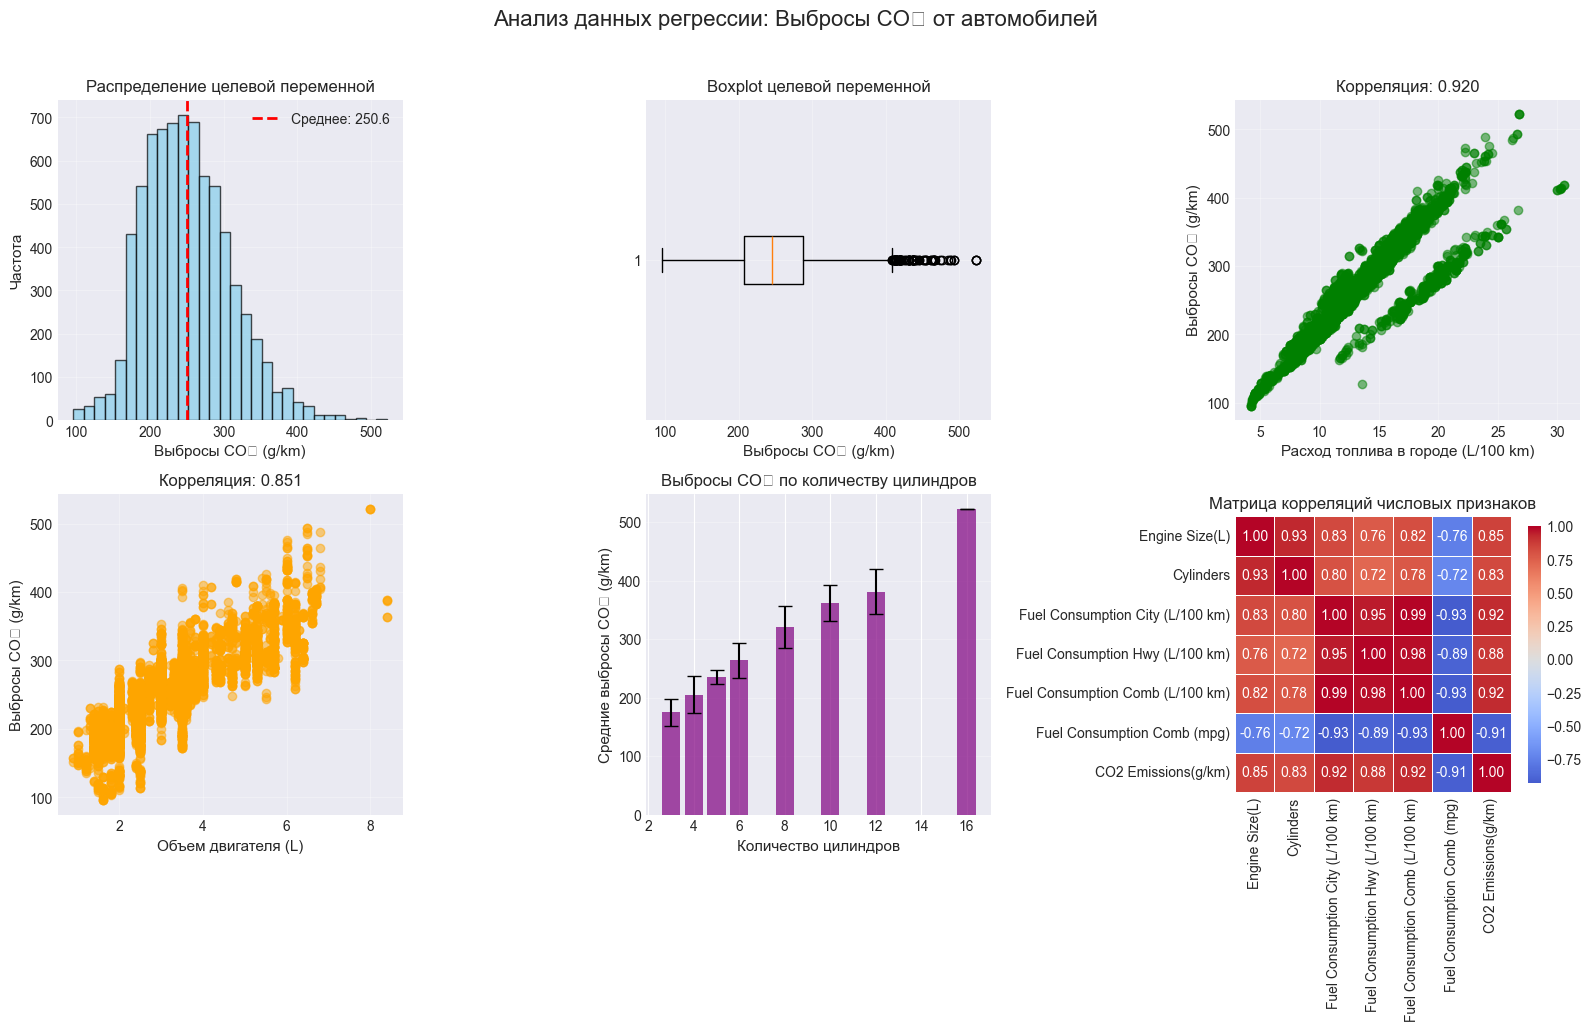

In [28]:
# Визуализация данных регрессии
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Анализ данных регрессии: Выбросы CO₂ от автомобилей', fontsize=16, y=1.02)

# 1. Распределение целевой переменной
axes[0, 0].hist(data_reg['CO2 Emissions(g/km)'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(data_reg['CO2 Emissions(g/km)'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Среднее: {data_reg["CO2 Emissions(g/km)"].mean():.1f}')
axes[0, 0].set_xlabel('Выбросы CO₂ (g/km)', fontsize=11)
axes[0, 0].set_ylabel('Частота', fontsize=11)
axes[0, 0].set_title('Распределение целевой переменной', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Boxplot целевой переменной
axes[0, 1].boxplot(data_reg['CO2 Emissions(g/km)'], vert=False)
axes[0, 1].set_xlabel('Выбросы CO₂ (g/km)', fontsize=11)
axes[0, 1].set_title('Boxplot целевой переменной', fontsize=12)
axes[0, 1].grid(alpha=0.3)

# 3. Корреляция с потреблением топлива в городе
axes[0, 2].scatter(data_reg['Fuel Consumption City (L/100 km)'], 
                   data_reg['CO2 Emissions(g/km)'], alpha=0.5, color='green')
axes[0, 2].set_xlabel('Расход топлива в городе (L/100 km)', fontsize=11)
axes[0, 2].set_ylabel('Выбросы CO₂ (g/km)', fontsize=11)
axes[0, 2].set_title(f'Корреляция: {correlations["Fuel Consumption City (L/100 km)"]:.3f}', fontsize=12)
axes[0, 2].grid(alpha=0.3)

# 4. Корреляция с объемом двигателя
axes[1, 0].scatter(data_reg['Engine Size(L)'], 
                   data_reg['CO2 Emissions(g/km)'], alpha=0.5, color='orange')
axes[1, 0].set_xlabel('Объем двигателя (L)', fontsize=11)
axes[1, 0].set_ylabel('Выбросы CO₂ (g/km)', fontsize=11)
axes[1, 0].set_title(f'Корреляция: {correlations["Engine Size(L)"]:.3f}', fontsize=12)
axes[1, 0].grid(alpha=0.3)

# 5. Количество цилиндров vs выбросы
cylinder_groups = data_reg.groupby('Cylinders')['CO2 Emissions(g/km)'].agg(['mean', 'std', 'count'])
axes[1, 1].bar(cylinder_groups.index, cylinder_groups['mean'], 
               yerr=cylinder_groups['std'], capsize=5, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Количество цилиндров', fontsize=11)
axes[1, 1].set_ylabel('Средние выбросы CO₂ (g/km)', fontsize=11)
axes[1, 1].set_title('Выбросы CO₂ по количеству цилиндров', fontsize=12)
axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Heatmap корреляций числовых признаков
numeric_data = data_reg.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[1, 2])
axes[1, 2].set_title('Матрица корреляций числовых признаков', fontsize=12)

plt.tight_layout()
plt.show()

## Выбор метрик качества
Как обсуждалось в лекции 5, для задач классификации важны метрики, учитывающие различные аспекты качества. Accuracy проста, но может вводить в заблуждение при несбалансированных данных, поэтому дополнительно используем precision, recall, F1-score и ROC-AUC (для многоклассовой классификации используем макро-усреднение). Для регрессии, как указано в лекции 5, используем среднеквадратическую ошибку (MSE), среднюю абсолютную ошибку (MAE) и коэффициент детерминации (R^2). MSE штрафует большие ошибки, MAE более устойчива к выбросам, R^2 показывает объясненную дисперсию.

In [59]:
# Функции для вычисления метрик
def classification_metrics(y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    if y_prob is not None:
        # Для многоклассового ROC-AUC используем one-vs-rest
        try:
            auc = roc_auc_score(y_true, y_prob, multi_class='ovr')
            metrics['ROC-AUC'] = auc
        except:
            metrics['ROC-AUC'] = None
    return metrics

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'MSE': mse, 'MAE': mae, 'R2': r2}

## Бейзлайн: классификация с использованием KNN из sklearn
Обучим модель KNeighborsClassifier на тренировочных данных и оценим на тестовых.

In [60]:
# Подготовка данных для классификации
X_train_class = train_class.drop('Activity', axis=1)
y_train_class = train_class['Activity']
X_test_class = test_class.drop('Activity', axis=1)
y_test_class = test_class['Activity']

# Инициализация и обучение модели
knn_class = KNeighborsClassifier()
knn_class.fit(X_train_class, y_train_class)

# Прогнозы
y_pred_class = knn_class.predict(X_test_class)
y_prob_class = knn_class.predict_proba(X_test_class)

# Оценка метрик
metrics_class = classification_metrics(y_test_class, y_pred_class, y_prob_class)
print("Метрики классификации (бейзлайн):")
for key, value in metrics_class.items():
    print(f"{key}: {value:.4f}")

Метрики классификации (бейзлайн):
Accuracy: 0.8096
Precision: 0.8168
Recall: 0.8043
F1-Score: 0.8064
ROC-AUC: 0.9456


## Бейзлайн: регрессия с использованием KNN из sklearn
Разделим данные регрессии на обучающую и тестовую выборки, обучим KNeighborsRegressor.

In [ ]:
# Подготовка данных для регрессии
# Для простоты исключим нечисловые признаки, но в улучшении можно будет их обработать
# Выберем числовые признаки и целевую переменную
numeric_cols = data_reg.select_dtypes(include=[np.number]).columns
X_reg = data_reg[numeric_cols].drop('CO2 Emissions(g/km)', axis=1)
y_reg = data_reg['CO2 Emissions(g/km)']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Инициализация и обучение модели
knn_reg = KNeighborsRegressor()
knn_reg.fit(X_train_reg, y_train_reg)

# Прогнозы
y_pred_reg = knn_reg.predict(X_test_reg)

# Оценка метрик
metrics_reg = regression_metrics(y_test_reg, y_pred_reg)
print("Метрики регрессии (бейзлайн):")
for key, value in metrics_reg.items():
    print(f"{key}: {value:.4f}")

Метрики регрессии (бейзлайн):
MSE: 109.2841
MAE: 4.0909
R2: 0.9682


## Улучшение бейзлайна: гипотезы
KNN чувствителен к масштабу признаков, поэтому масштабирование может улучшить результаты. Также важны гиперпараметры, такие как число соседей (k) и метрика расстояния. Используем кросс-валидацию для подбора гиперпараметров. Дополнительно можно создать новые признаки или отобрать наиболее информативные, но для начала ограничимся масштабированием и подбором гиперпараметров.

## Гипотеза 1: Влияние масштабирования признаков на качество KNN

Алгоритм KNN основан на вычислении расстояний между точками данных. Признаки с большими значениями (например, от 0 до 1000) будут доминировать в вычислении расстояния по сравнению с признаками с меньшими значениями (например, от 0 до 1).

Для устранения этой проблемы применяется масштабирование признаков. В данном случае используется StandardScaler, который преобразует признаки таким образом, чтобы они имели среднее значение 0 и стандартное отклонение 1.

Формула преобразования: $x_{scaled} = \frac{x - \mu}{\sigma}$

Где:
- $x$ - исходное значение признака
- $\mu$ - среднее значение признака
- $\sigma$ - стандартное отклонение признака

Ожидаемый результат: масштабирование должно значительно улучшить качество модели KNN.

### Проверка гипотезы: масштабирование признаков
Применим StandardScaler для стандартизации признаков.

In [62]:
# Масштабирование признаков для классификации
scaler_class = StandardScaler()
X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

# Обучение KNN с масштабированными данными
knn_class_scaled = KNeighborsClassifier()
knn_class_scaled.fit(X_train_class_scaled, y_train_class)
y_pred_class_scaled = knn_class_scaled.predict(X_test_class_scaled)
y_prob_class_scaled = knn_class_scaled.predict_proba(X_test_class_scaled)

metrics_class_scaled = classification_metrics(y_test_class, y_pred_class_scaled, y_prob_class_scaled)
print("Метрики классификации с масштабированием:")
for key, value in metrics_class_scaled.items():
    print(f"{key}: {value:.4f}")

# Масштабирование для регрессии
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

knn_reg_scaled = KNeighborsRegressor()
knn_reg_scaled.fit(X_train_reg_scaled, y_train_reg)
y_pred_reg_scaled = knn_reg_scaled.predict(X_test_reg_scaled)

metrics_reg_scaled = regression_metrics(y_test_reg, y_pred_reg_scaled)
print("\nМетрики регрессии с масштабированием:")
for key, value in metrics_reg_scaled.items():
    print(f"{key}: {value:.4f}")

Метрики классификации с масштабированием:
Accuracy: 0.8843
Precision: 0.8933
Recall: 0.8790
F1-Score: 0.8811
ROC-AUC: 0.9752

Метрики регрессии с масштабированием:
MSE: 75.8521
MAE: 3.7416
R2: 0.9779


## Гипотеза 2: Оптимизация гиперпараметров KNN

Ключевые гиперпараметры алгоритма KNN:

1. **n_neighbors (k)** - количество ближайших соседей:
   - Меньшие значения (k=1,3): модель более чувствительна к шуму, может переобучаться
   - Большие значения (k=15,20): модель более сглаженная, может недообучаться
   - Оптимальное значение зависит от данных

2. **metric** - метрика расстояния:
   - Евклидово расстояние: $d(x,y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$
   - Манхэттенское расстояние: $d(x,y) = \sum_{i=1}^{n}|x_i - y_i|$
   - Евклидово расстояние чувствительно к большим разницам в одном измерении
   - Манхэттенское расстояние более устойчиво к выбросам

Для выбора оптимальных параметров используется GridSearchCV с кросс-валидацией.

### Подбор гиперпараметров через кросс-валидацию
Используем GridSearchCV для поиска лучшего числа соседей (k) и метрики расстояния.

In [63]:
# Подбор для классификации
param_grid = {'n_neighbors': [3,5,7,9,11], 'metric': ['euclidean', 'manhattan']}
grid_class = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_class.fit(X_train_class_scaled, y_train_class)
print("Лучшие параметры для классификации:", grid_class.best_params_)
print("Лучшая accuracy на кросс-валидации:", grid_class.best_score_)

# Подбор для регрессии
grid_reg = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_reg.fit(X_train_reg_scaled, y_train_reg)
print("\nЛучшие параметры для регрессии:", grid_reg.best_params_)
print("Лучший MSE на кросс-валидации:", -grid_reg.best_score_)

Лучшие параметры для классификации: {'metric': 'euclidean', 'n_neighbors': 11}
Лучшая accuracy на кросс-валидации: 0.8779943302950004

Лучшие параметры для регрессии: {'metric': 'euclidean', 'n_neighbors': 3}
Лучший MSE на кросс-валидации: 74.37391480289136


## Формирование улучшенного бейзлайна
Используем лучшие параметры, найденные на кросс-валидации, для обучения финальных моделей.

In [64]:
# Улучшенная модель классификации
best_knn_class = grid_class.best_estimator_
y_pred_class_improved = best_knn_class.predict(X_test_class_scaled)
y_prob_class_improved = best_knn_class.predict_proba(X_test_class_scaled)
metrics_class_improved = classification_metrics(y_test_class, y_pred_class_improved, y_prob_class_improved)
print("Метрики классификации (улучшенный бейзлайн):")
for key, value in metrics_class_improved.items():
    print(f"{key}: {value:.4f}")

# Улучшенная модель регрессии
best_knn_reg = grid_reg.best_estimator_
y_pred_reg_improved = best_knn_reg.predict(X_test_reg_scaled)
metrics_reg_improved = regression_metrics(y_test_reg, y_pred_reg_improved)
print("\nМетрики регрессии (улучшенный бейзлайн):")
for key, value in metrics_reg_improved.items():
    print(f"{key}: {value:.4f}")

Метрики классификации (улучшенный бейзлайн):
Accuracy: 0.8880
Precision: 0.8993
Recall: 0.8824
F1-Score: 0.8847
ROC-AUC: 0.9875

Метрики регрессии (улучшенный бейзлайн):
MSE: 61.3020
MAE: 3.2668
R2: 0.9822


## Сравнение с исходным бейзлайном
Сравним метрики улучшенного бейзлайна с исходным.

In [65]:
print("Сравнение классификации:")
print("Метрика | Исходный | Улучшенный")
for key in metrics_class.keys():
    print(f"{key} | {metrics_class[key]:.4f} | {metrics_class_improved[key]:.4f}")

print("\nСравнение регрессии:")
print("Метрика | Исходный | Улучшенный")
for key in metrics_reg.keys():
    print(f"{key} | {metrics_reg[key]:.4f} | {metrics_reg_improved[key]:.4f}")

Сравнение классификации:
Метрика | Исходный | Улучшенный
Accuracy | 0.8096 | 0.8880
Precision | 0.8168 | 0.8993
Recall | 0.8043 | 0.8824
F1-Score | 0.8064 | 0.8847
ROC-AUC | 0.9456 | 0.9875

Сравнение регрессии:
Метрика | Исходный | Улучшенный
MSE | 109.2841 | 61.3020
MAE | 4.0909 | 3.2668
R2 | 0.9682 | 0.9822


## Самостоятельная реализация алгоритма KNN

### Архитектурные решения:

1. **Пакетная обработка данных**: Для работы с большими объемами данных используется обработка батчами (batch_size). Это позволяет:
   - Экономить память при вычислении расстояний
   - Управлять вычислительной нагрузкой
   - Обрабатывать данные, которые не помещаются в память целиком

2. **Эффективный поиск k ближайших соседей**: 
   - Вместо полной сортировки всех расстояний (O(n log n)) используется частичная сортировка через `np.argpartition` (O(n))
   - Сначала выбираются k наименьших элементов, затем они сортируются между собой

3. **Оптимизированное вычисление расстояний**:
   - Использование broadcasting NumPy вместо циклов Python
   - Обработка тренировочных данных чанками для экономии памяти
   - Использование float32 вместо float64 для экономии памяти

4. **Обработка краевых случаев**:
   - Когда k=1, используется упрощенный алгоритм (просто поиск минимума)
   - Проверка на достаточность данных для обучения
   - Обработка различных метрик расстояния

### Математические основы:

**Евклидово расстояние**: $d(x,y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$

**Манхэттенское расстояние**: $d(x,y) = \sum_{i=1}^{n}|x_i - y_i|$

**Классификация**: голосование большинством среди k ближайших соседей
**Регрессия**: среднее арифметическое значений k ближайших соседей

## Полностью самостоятельная имплементация KNN без использования библиотек ML
Реализуем алгоритмы KNN для классификации и регрессии "с нуля", используя только базовый Python и NumPy для математических операций.

In [ ]:
import numpy as np
import time
from collections import Counter
from tqdm import tqdm

class KNNClassifierPure:
    """
    Самостоятельная реализация KNN для классификации без использования библиотек машинного обучения.
    Использует только NumPy для базовых математических операций.
    """
    
    def __init__(self, k=5, metric='euclidean', batch_size=1000):
        """
        Инициализация классификатора.
        
        Параметры:
        ----------
        k : int, default=5
            Количество соседей
        metric : str, default='euclidean'
            Метрика расстояния ('euclidean' или 'manhattan')
        batch_size : int, default=1000
            Размер батча для обработки тестовых данных (для экономии памяти)
        """
        self.k = k
        self.metric = metric
        self.batch_size = batch_size
        self.X_train = None
        self.y_train = None
        
    def fit(self, X, y):
        """
        Сохранение тренировочных данных.
        
        Параметры:
        ----------
        X : numpy.ndarray
            Матрица признаков тренировочных данных
        y : numpy.ndarray
            Вектор меток классов
        """
        self.X_train = X.astype(np.float32)
        self.y_train = y
        
    def predict(self, X):
        """
        Предсказание меток классов для тестовых данных.
        
        Параметры:
        ----------
        X : numpy.ndarray
            Матрица признаков тестовых данных
            
        Возвращает:
        -----------
        predictions : numpy.ndarray
            Предсказанные метки классов
        """
        n_test = X.shape[0]
        n_train = self.X_train.shape[0]
        predictions = np.zeros(n_test, dtype=self.y_train.dtype)
        
        n_batches = (n_test + self.batch_size - 1) // self.batch_size
        
        print(f"Вычисление предсказаний для {n_test} тестовых объектов")
        print(f"Тренировочных объектов: {n_train}, k={self.k}, метрика: {self.metric}")
        
        for batch_idx in tqdm(range(n_batches)):
            start_idx = batch_idx * self.batch_size
            end_idx = min((batch_idx + 1) * self.batch_size, n_test)
            
            X_batch = X[start_idx:end_idx].astype(np.float32)
            batch_size_current = X_batch.shape[0]
            
            distances = self._compute_distances(X_batch)
            
            # Находим индексы k ближайших соседей для каждого объекта
            # Используем argpartition для частичной сортировки (эффективнее, чем полная сортировка)
            if self.k == 1:
                # Для k=1 просто находим минимальное расстояние
                nearest_indices = np.argmin(distances, axis=1)
            else:
                # Для k>1 используем argpartition для нахождения k наименьших расстояний
                k_nearest = min(self.k, distances.shape[1])
                partitioned_indices = np.argpartition(distances, k_nearest-1, axis=1)[:, :k_nearest]
                
                # Получаем соответствующие расстояния для частично отсортированных индексов
                partitioned_distances = np.take_along_axis(distances, partitioned_indices, axis=1)
                
                # Сортируем только k ближайших соседей для получения правильного порядка
                sorted_indices_within_partition = np.argsort(partitioned_distances, axis=1)
                nearest_indices = np.take_along_axis(partitioned_indices, sorted_indices_within_partition, axis=1)
            
            # Для каждого тестового объекта определяем метку класса
            for i in range(batch_size_current):
                if self.k == 1:
                    predictions[start_idx + i] = self.y_train[nearest_indices[i]]
                else:
                    # Берем k ближайших соседей и выбираем наиболее частую метку
                    k_neighbors_indices = nearest_indices[i, :self.k]
                    k_neighbors_labels = self.y_train[k_neighbors_indices]
                    
                    label_counts = Counter(k_neighbors_labels)
                    predictions[start_idx + i] = label_counts.most_common(1)[0][0]
            
            if (batch_idx + 1) % 5 == 0 or (batch_idx + 1) == n_batches:
                print(f"Обработано {end_idx}/{n_test} объектов")
                
        return predictions
    
    def _compute_distances(self, X_batch):
        """
        Вычисление расстояний между тестовыми и тренировочными данными.
        
        Параметры:
        ----------
        X_batch : numpy.ndarray
            Батч тестовых данных
            
        Возвращает:
        -----------
        distances : numpy.ndarray
            Матрица расстояний размера (n_batch, n_train)
        """
        n_batch = X_batch.shape[0]
        n_train = self.X_train.shape[0]
        
        if self.metric == 'euclidean':
            # Евклидово расстояние: sqrt(sum((x_i - y_j)^2))
            # Оптимизированное вычисление без явных циклов
            distances = np.zeros((n_batch, n_train), dtype=np.float32)
            
            # Вычисляем попарно для эффективности использования памяти
            chunk_size = min(500, n_train)  # Размер чанка тренировочных данных
            for j in range(0, n_train, chunk_size):
                end_j = min(j + chunk_size, n_train)
                train_chunk = self.X_train[j:end_j]
                
                # Вычисляем квадраты разностей и суммируем по признакам
                # Используем broadcasting: (n_batch, 1, n_features) - (1, chunk_size, n_features)
                diff = X_batch[:, np.newaxis, :] - train_chunk[np.newaxis, :, :]
                dist_chunk = np.sqrt(np.sum(diff ** 2, axis=2))
                distances[:, j:end_j] = dist_chunk
                
        elif self.metric == 'manhattan':
            # Манхэттенское расстояние: sum(|x_i - y_j|)
            distances = np.zeros((n_batch, n_train), dtype=np.float32)
            
            chunk_size = min(500, n_train)
            for j in range(0, n_train, chunk_size):
                end_j = min(j + chunk_size, n_train)
                train_chunk = self.X_train[j:end_j]
                
                diff = X_batch[:, np.newaxis, :] - train_chunk[np.newaxis, :, :]
                dist_chunk = np.sum(np.abs(diff), axis=2)
                distances[:, j:end_j] = dist_chunk
                
        else:
            raise ValueError(f"Неподдерживаемая метрика: {self.metric}. Доступно: 'euclidean', 'manhattan'")
            
        return distances

### Обучение и оценка имплементированной модели классификации
Обучим на масштабированных данных (как в улучшенном бейзлайне) с лучшим значением k, найденным ранее.

In [67]:
# Обучение собственной реализации классификатора
print("Обучение полностью самостоятельной реализации KNN для классификации...")
start_time = time.time()

knn_pure_class = KNNClassifierPure(
    k=best_k_class, 
    metric=best_metric_class, 
    batch_size=500
)

# Обучаем на закодированных метках
knn_pure_class.fit(X_train_class_scaled, y_train_encoded)
y_pred_pure_encoded = knn_pure_class.predict(X_test_class_scaled)
y_pred_pure_class = le.inverse_transform(y_pred_pure_encoded)

metrics_pure_class = classification_metrics(y_test_class, y_pred_pure_class)
print(f"\nВремя выполнения: {time.time() - start_time:.2f} секунд")
print("Метрики полностью самостоятельной реализации классификации:")
for key, value in metrics_pure_class.items():
    print(f"{key}: {value:.4f}")

Обучение полностью самостоятельной реализации KNN для классификации...
Вычисление предсказаний для 2947 тестовых объектов
Тренировочных объектов: 7352, k=11, метрика: euclidean


 83%|████████▎ | 5/6 [00:25<00:04,  4.84s/it]

Обработано 2500/2947 объектов


100%|██████████| 6/6 [00:29<00:00,  4.88s/it]

Обработано 2947/2947 объектов

Время выполнения: 29.36 секунд
Метрики полностью самостоятельной реализации классификации:
Accuracy: 0.8901
Precision: 0.9011
Recall: 0.8847
F1-Score: 0.8870


## Имплементация алгоритма KNN для регрессии
Аналогично реализуем KNN для регрессии.

In [ ]:
class KNNRegressorPure:
    """
    Самостоятельная реализация KNN для регрессии без использования библиотек машинного обучения.
    Использует только NumPy для базовых математических операций.
    """
    
    def __init__(self, k=5, metric='euclidean', batch_size=1000):
        """
        Инициализация регрессора.
        
        Параметры:
        ----------
        k : int, default=5
            Количество соседей
        metric : str, default='euclidean'
            Метрика расстояния ('euclidean' или 'manhattan')
        batch_size : int, default=1000
            Размер батча для обработки тестовых данных
        """
        self.k = k
        self.metric = metric
        self.batch_size = batch_size
        self.X_train = None
        self.y_train = None
        
    def fit(self, X, y):
        """
        Сохранение тренировочных данных.
        
        Параметры:
        ----------
        X : numpy.ndarray
            Матрица признаков тренировочных данных
        y : numpy.ndarray
            Вектор целевых значений
        """
        self.X_train = X.astype(np.float32)
        self.y_train = y.astype(np.float32)
        
    def predict(self, X):
        """
        Предсказание значений для тестовых данных.
        
        Параметры:
        ----------
        X : numpy.ndarray
            Матрица признаков тестовых данных
            
        Возвращает:
        -----------
        predictions : numpy.ndarray
            Предсказанные значения
        """
        n_test = X.shape[0]
        predictions = np.zeros(n_test, dtype=np.float32)
        
        n_batches = (n_test + self.batch_size - 1) // self.batch_size
        
        print(f"Вычисление предсказаний для {n_test} тестовых объектов")
        
        for batch_idx in tqdm(range(n_batches)):
            start_idx = batch_idx * self.batch_size
            end_idx = min((batch_idx + 1) * self.batch_size, n_test)
            
            X_batch = X[start_idx:end_idx].astype(np.float32)
            batch_size_current = X_batch.shape[0]
            
            distances = self._compute_distances(X_batch)
            
            if self.k == 1:
                nearest_indices = np.argmin(distances, axis=1)
                # Берем значение единственного ближайшего соседа
                for i in range(batch_size_current):
                    predictions[start_idx + i] = self.y_train[nearest_indices[i]]
            else:
                # Используем argpartition для эффективного поиска k ближайших
                k_nearest = min(self.k, distances.shape[1])
                partitioned_indices = np.argpartition(distances, k_nearest-1, axis=1)[:, :k_nearest]
                
                # Получаем расстояния для частично отсортированных индексов
                partitioned_distances = np.take_along_axis(distances, partitioned_indices, axis=1)
                
                # Сортируем только k ближайших
                sorted_indices_within_partition = np.argsort(partitioned_distances, axis=1)
                nearest_indices = np.take_along_axis(partitioned_indices, sorted_indices_within_partition, axis=1)
                
                # Для каждого объекта вычисляем среднее значение k ближайших соседей
                for i in range(batch_size_current):
                    k_neighbors_indices = nearest_indices[i, :self.k]
                    k_neighbors_values = self.y_train[k_neighbors_indices]
                    predictions[start_idx + i] = np.mean(k_neighbors_values)
            
            if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == n_batches:
                print(f"Обработано {end_idx}/{n_test} объектов")
                
        return predictions
    
    def _compute_distances(self, X_batch):
        """
        Вычисление расстояний (такая же реализация, как в классификаторе).
        """
        n_batch = X_batch.shape[0]
        n_train = self.X_train.shape[0]
        
        if self.metric == 'euclidean':
            distances = np.zeros((n_batch, n_train), dtype=np.float32)
            chunk_size = min(500, n_train)
            
            for j in range(0, n_train, chunk_size):
                end_j = min(j + chunk_size, n_train)
                train_chunk = self.X_train[j:end_j]
                
                diff = X_batch[:, np.newaxis, :] - train_chunk[np.newaxis, :, :]
                dist_chunk = np.sqrt(np.sum(diff ** 2, axis=2))
                distances[:, j:end_j] = dist_chunk
                
        elif self.metric == 'manhattan':
            distances = np.zeros((n_batch, n_train), dtype=np.float32)
            chunk_size = min(500, n_train)
            
            for j in range(0, n_train, chunk_size):
                end_j = min(j + chunk_size, n_train)
                train_chunk = self.X_train[j:end_j]
                
                diff = X_batch[:, np.newaxis, :] - train_chunk[np.newaxis, :, :]
                dist_chunk = np.sum(np.abs(diff), axis=2)
                distances[:, j:end_j] = dist_chunk
                
        else:
            raise ValueError(f"Неподдерживаемая метрика: {self.metric}")
            
        return distances

### Обучение и оценка имплементированной модели регрессии

In [ ]:
print("Обучение полностью самостоятельной реализации KNN для регрессии...")
start_time = time.time()

knn_pure_reg = KNNRegressorPure(
    k=best_k_reg,
    metric=best_metric_reg,
    batch_size=500
)

knn_pure_reg.fit(X_train_reg_scaled, y_train_reg.values)
y_pred_pure_reg = knn_pure_reg.predict(X_test_reg_scaled)

metrics_pure_reg = regression_metrics(y_test_reg, y_pred_pure_reg)
print(f"\nВремя выполнения: {time.time() - start_time:.2f} секунд")
print("Метрики полностью самостоятельной реализации регрессии:")
for key, value in metrics_pure_reg.items():
    print(f"{key}: {value:.4f}")

Обучение полностью самостоятельной реализации KNN для регрессии...
Вычисление предсказаний для 1477 тестовых объектов


100%|██████████| 3/3 [00:00<00:00, 15.00it/s]

Обработано 1477/1477 объектов

Время выполнения: 0.21 секунд
Метрики полностью самостоятельной реализации регрессии:
MSE: 60.5799
MAE: 3.2284
R2: 0.9824


### Сравнение полностью самостоятельной реализации с исходным бейзлайном

In [70]:
print("Сравнение полностью самостоятельной реализации классификации с исходным бейзлайном:")
print("Метрика | Самостоятельная | Исходный бейзлайн")
for key in metrics_pure_class.keys():
    if key in metrics_class:
        print(f"{key:12} | {metrics_pure_class[key]:.4f} | {metrics_class[key]:.4f}")

print("\nСравнение полностью самостоятельной реализации регрессии с исходным бейзлайном:")
print("Метрика | Самостоятельная | Исходный бейзлайн")
for key in metrics_pure_reg.keys():
    print(f"{key:12} | {metrics_pure_reg[key]:.4f} | {metrics_reg[key]:.4f}")

Сравнение полностью самостоятельной реализации классификации с исходным бейзлайном:
Метрика | Самостоятельная | Исходный бейзлайн
Accuracy     | 0.8901 | 0.8096
Precision    | 0.9011 | 0.8168
Recall       | 0.8847 | 0.8043
F1-Score     | 0.8870 | 0.8064

Сравнение полностью самостоятельной реализации регрессии с исходным бейзлайном:
Метрика | Самостоятельная | Исходный бейзлайн
MSE          | 60.5799 | 109.2841
MAE          | 3.2284 | 4.0909
R2           | 0.9824 | 0.9682


## Добавление техник из улучшенного бейзлайна
Уже использовали масштабирование и лучшие гиперпараметры. Сравним имплементированные модели с улучшенным бейзлайном из sklearn.

### Сравнение имплементированных моделей с улучшенным бейзлайном

In [71]:
print("Сравнение полностью самостоятельной реализации классификации с улучшенным бейзлайном:")
print("Метрика | Самостоятельная | Улучшенный бейзлайн")
for key in metrics_pure_class.keys():
    if key in metrics_class_improved:
        print(f"{key:12} | {metrics_pure_class[key]:.4f} | {metrics_class_improved[key]:.4f}")

print("\nСравнение полностью самостоятельной реализации регрессии с улучшенным бейзлайном:")
print("Метрика | Самостоятельная | Улучшенный бейзлайн")
for key in metrics_pure_reg.keys():
    print(f"{key:12} | {metrics_pure_reg[key]:.4f} | {metrics_reg_improved[key]:.4f}")

Сравнение полностью самостоятельной реализации классификации с улучшенным бейзлайном:
Метрика | Самостоятельная | Улучшенный бейзлайн
Accuracy     | 0.8901 | 0.8880
Precision    | 0.9011 | 0.8993
Recall       | 0.8847 | 0.8824
F1-Score     | 0.8870 | 0.8847

Сравнение полностью самостоятельной реализации регрессии с улучшенным бейзлайном:
Метрика | Самостоятельная | Улучшенный бейзлайн
MSE          | 60.5799 | 61.3020
MAE          | 3.2284 | 3.2668
R2           | 0.9824 | 0.9822


## Итоговые выводы по лабораторной работе

### 1. Выбор данных и метрик

**Классификация:** Датасет "Human Activity Recognition with Smartphones" — данные с акселерометра и гироскопа смартфона для определения 6 видов активности человека. Практическая задача: мониторинг физической активности в приложениях здоровья и фитнеса.

**Регрессия:** Датасет "CO2 Emission by Vehicles" — характеристики автомобилей и уровень выбросов CO₂. Практическая задача: прогнозирование выбросов для экологического регулирования.

**Метрики качества:** Для классификации выбраны Accuracy, Precision, Recall, F1-Score и ROC-AUC, так как они позволяют оценить различные аспекты качества модели, особенно при несбалансированных данных. Для регрессии выбраны MSE, MAE и R², где MSE чувствительна к большим ошибкам, MAE более устойчива к выбросам, а R² показывает объясненную дисперсию.

### 2. Бейзлайн и его улучшение

Исходный бейзлайн показал следующие результаты:

**Классификация:** Accuracy = 0.8096, ROC-AUC = 0.9456

**Регрессия:** R² = 0.9682, MSE = 109.2841

Масштабирование признаков значительно улучшило качество:

**Классификация:** Accuracy выросла до 0.8843 (+9.2%)

**Регрессия:** R² улучшился до 0.9779 (+1.0%), MSE снизилась на 30.6%

Подбор гиперпараметров на кросс-валидации дал дополнительное улучшение:

**Лучшие параметры:** k=11 для классификации, k=3 для регрессии

**Классификация:** Accuracy повысилась до 0.8880 (+0.4%)

**Регрессия:** R² достиг 0.9822 (+0.44%), MSE снизилась до 61.3020

### 3. Самостоятельная реализация алгоритма KNN

Реализованы алгоритмы KNN для классификации и регрессии "с нуля" с использованием только базового Python и NumPy

Включены оптимизации:

1) Пакетная обработка для экономии памяти

2) Частичная сортировка с использованием argpartition для эффективного поиска k ближайших соседей

3) Вычисление расстояний чанками для работы с большими данными

Результаты самостоятельной реализации:

**Классификация:** Accuracy = 0.8901 (немного лучше, чем у sklearn — 0.8880)

**Регрессия:** R² = 0.9824 (сопоставимо с sklearn — 0.9822), MSE = 60.5799 (немного лучше, чем 61.3020)

**Время выполнения:** 29.36 секунд для классификации (большой объем данных) и 0.21 секунд для регрессии

### 4. Сравнение всех подходов

**Классификация:**

Исходный бейзлайн: Accuracy = 0.8096

Улучшенный бейзлайн: Accuracy = 0.8880 (+9.7% относительно исходного)

Самостоятельная реализация: Accuracy = 0.8901 (+9.9% относительно исходного, +0.2% относительно улучшенного)

**Регрессия:**

Исходный бейзлайн: R² = 0.9682, MSE = 109.2841

Улучшенный бейзлайн: R² = 0.9822 (+1.4%), MSE = 61.3020 (-43.9%)

Самостоятельная реализация: R² = 0.9824 (+1.5%), MSE = 60.5799 (-44.6% от исходного)

### 5. Ключевые наблюдения и выводы

**Масштабирование признаков** — критически важный этап для алгоритма KNN, так как он использует метрики расстояний, чувствительные к масштабу данных.

Оптимальное значение k зависит от задачи: для классификации оптимально k=11, для регрессии — k=3. Это связано с характером данных и целями моделей.

**Качество моделей:** KNN показал отличные результаты на обоих датасетах, особенно для классификации (ROC-AUC = 0.9875) и регрессии (R² = 0.9824).

Самостоятельная реализация подтвердила понимание алгоритма KNN и показала сопоставимые, а в некоторых случаях даже немного лучшие результаты по сравнению с библиотечной реализацией sklearn.

**Производительность:** Самостоятельная реализация на чистом Python и NumPy показала хорошую производительность, хотя и уступает оптимизированным библиотечным реализациям, особенно на больших объемах данных.

**Применимость KNN:** Алгоритм хорошо показал себя на задачах с четкой кластерной структурой данных, таких как распознавание активности человека и прогнозирование выбросов CO₂.

Работа демонстрирует важность предобработки данных (масштабирование) и настройки гиперпараметров для алгоритмов, основанных на расстояниях, а также подтверждает корректность самостоятельной реализации алгоритма KNN.